# Customer Cohort Analysis using the Olist E-Commerce Dataset

Analyzing customer retention behavior through cohort analysis to understand repeat purchase patterns and customer lifetime trends.

## Project Objective

The objective of this project is to analyze customer retention using cohort analysis.

The analysis groups customers based on the month of their first purchase and tracks their repeat purchasing behavior over time. This helps evaluate customer retention, identify long-term purchasing trends, and generate actionable business recommendations.

## Dataset

Source: Olist Brazilian E-Commerce Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data Preparation And Performing Basic Steps

In [38]:
cust_data = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_customers_dataset.csv')
order_items = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_order_items_dataset.csv')
order_data = pd.read_csv(r'/Users/aryan/Downloads/archive (8)/olist_orders_dataset.csv')

In [39]:
cust_data.head(2)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP


In [40]:
order_data.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


In [41]:
df = order_data.merge(cust_data[['customer_id','customer_unique_id']], on = 'customer_id', how = 'inner')
df.head(2)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231


In [42]:
df.shape

(99441, 9)

In [43]:
df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
customer_unique_id                  0
dtype: int64

In [44]:
df['customer_unique_id'].nunique()

96096

In [45]:
df['order_id'].nunique()

99441

In [46]:
# This verifies that we have customers who ordered more than once. If customers didnt order more than once, then cohort analyis and rfm
# analysis would be very difficult.

In [47]:
df.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
customer_unique_id               object
dtype: object

In [48]:
# We need to convert order_purchase_timestamp into date format. Also we are dropping cols that we dont need. 
df = df.drop(columns = ['order_approved_at','order_delivered_carrier_date','order_status',
                        'order_delivered_customer_date','order_estimated_delivery_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [49]:
df.head(2)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231


In [50]:
# Much cleaner

# Finding Each Customer's First Purchase

In [51]:
first_purchase = df.groupby(by = 'customer_unique_id')['order_purchase_timestamp'].min()
first_purchase.head()

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2   2018-05-10 10:56:27
0000b849f77a49e4a4ce2b2a4ca5be3f   2018-05-07 11:11:27
0000f46a3911fa3c0805444483337064   2017-03-10 21:05:03
0000f6ccb0745a6a4b88665a16c9f078   2017-10-12 20:29:41
0004aac84e0df4da2b147fca70cf8255   2017-11-14 19:45:42
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [52]:
# Attaching first purchase back in df

df['first_purchase_date'] = df.groupby(by = 'customer_unique_id')['order_purchase_timestamp'].transform('min')
df.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,first_purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


In [59]:
# Making a cohort_month

df['cohort_month'] = df['first_purchase_date'].dt.to_period('M')

In [60]:
# Mow suppose a customer bought in jan, feb and march. Then cohort_month would show jan, jan , jan.
# So we create a purchse_month to get to know in which month they purchsed again

df['purchase_month'] = df['order_purchase_timestamp'].dt.to_period('M')
df.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,first_purchase_date,cohort_month,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38,2017-09,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02


In [66]:
# Now we need to create cohort index. 0 -> month of purchsse. 1->1st month after purchasing, and so on

df['cohort_month_num'] = df['cohort_month'].dt.month
df['cohort_year'] = df['cohort_month'].dt.year

df['purchase_month_num'] = df['purchase_month'].dt.month
df['purchase_year'] = df['purchase_month'].dt.year
df.head(2)

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,first_purchase_date,cohort_month,purchase_month,cohort_month_num,cohort_year,purchase_month_num,purchase_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38,2017-09,2017-10,9,2017,10,2017
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07,7,2018,7,2018


# Cohort Index Calculation

In [67]:
# Now we do the calculations. 

df['cohort_index'] = (df['purchase_month_num'] - df['cohort_month_num']) + (df['purchase_year'] - df['cohort_year'])*12
df.head()

,order_id,customer_id,order_purchase_timestamp,customer_unique_id,first_purchase_date,cohort_month,purchase_month,cohort_month_num,cohort_year,purchase_month_num,purchase_year,cohort_index
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-09-04 11:26:38,2017-09,2017-10,9,2017,10,2017,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07,7,2018,7,2018,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08,8,2018,8,2018,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11,11,2017,11,2017,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02,2,2018,2,2018,0


In [80]:
# Now we will look at how many people bought initially . like for 09-2016, at index = 0 are the customers who first purchased in 09-2016,
# then for the same 09-2016, at cohort_index = 1 means customers who repurchased in 10-2016

cohort_data = df.groupby(by = ['cohort_month','cohort_index'])['customer_unique_id'].nunique().reset_index(name = 'total_customers')

cohort_data

,cohort_month,cohort_index,total_customers
0,2016-09,0,4
1,2016-10,0,321
2,2016-10,6,1
3,2016-10,9,1
4,2016-10,11,1
...,...,...,...
220,2018-08,0,6271
221,2018-08,1,7
222,2018-08,2,2
223,2018-09,0,5


# Building the Cohort Matrix

In [90]:
# Creating a pivot table to visualize our data better
cohort_pivot = cohort_data.pivot(index = 'cohort_month', columns = 'cohort_index', values = 'total_customers')

# Filling the null -> 0
cohort_pivot = cohort_pivot.fillna(0)

cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10,321.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,2.0
2016-12,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,0.0,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,0.0
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,0.0,0.0


# Retention Rate Calculation

In [93]:
# Now we need to create cohort percentages to view all of them evenly.
# Calculating percentages
retention = cohort_pivot.copy()

for col in cohort_pivot.columns:
    retention[col] = (cohort_pivot[col]*100)/cohort_pivot[0]

retention = retention.round(2)
retention.head()

# Alternate way to do it :
# retention = cohort_pivot.divide(cohort_pivot[0],axis = 0)


cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2016-10,100.0,0.00,0.00,0.00,0.00,0.00,0.31,0.00,0.00,0.31,0.00,0.31,0.00,0.31,0.00,0.31,0.00,0.31,0.62,0.62
2016-12,100.0,100.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2017-01,100.0,0.39,0.26,0.13,0.39,0.13,0.52,0.13,0.13,0.00,0.39,0.13,0.79,0.39,0.13,0.13,0.26,0.39,0.13,0.00
2017-02,100.0,0.23,0.29,0.11,0.40,0.11,0.23,0.17,0.17,0.23,0.11,0.29,0.17,0.17,0.11,0.06,0.06,0.23,0.00,0.00


# Retention Heatmap

The cohort retention matrix visualizes the percentage of customers returning in subsequent months after their first purchase.

<Axes: xlabel='cohort_index', ylabel='cohort_month'>

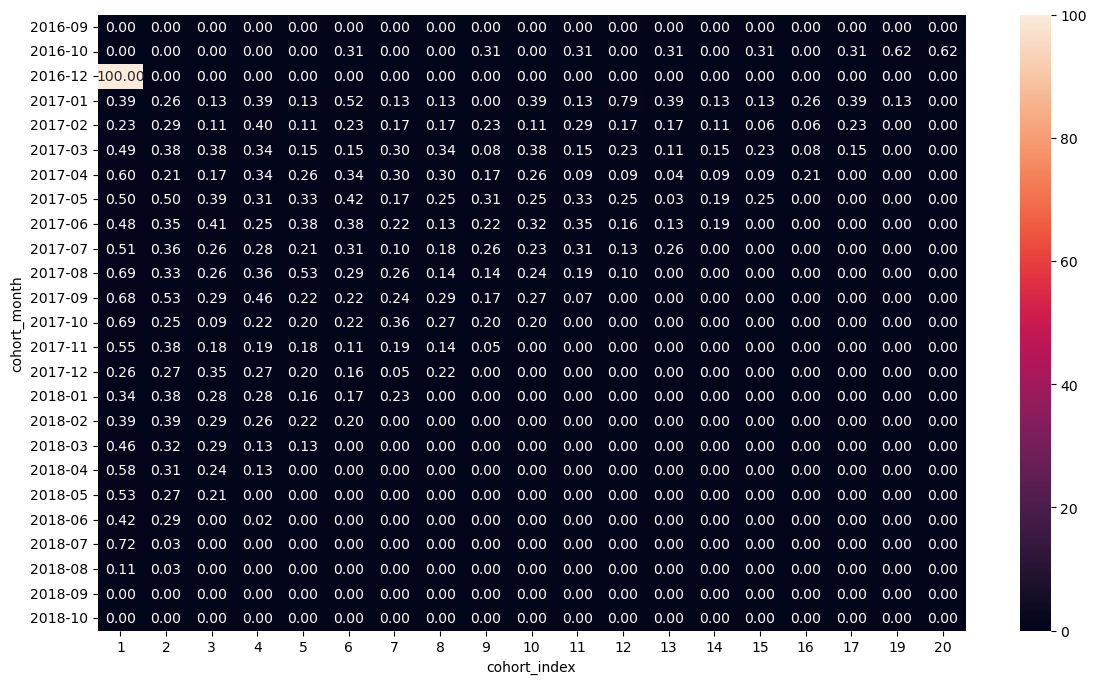

In [102]:
# Since month0 = 100% always, so we dont actually need it. Making a new retention_heatmap for it.

retention_heatmap = retention.drop(columns = [0])

plt.figure(figsize = (14,8))
sns.heatmap(retention_heatmap, annot = True, fmt = '.2f')



# Average Retention Curve 
We can calculate normal average, we can notice that in 2016-12, one customer purchased, who again purchased in next month. that technically means 
retention is 100%. but it is insignifcant. ex : 600 cusotmers returning after 1 month out of 1200 has a retetion of 50% ,
which is far better. so we will have to calculate the weighted average

In [108]:
cohort_pivot.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10,321.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,2.0,2.0
2016-12,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01,764.0,3.0,2.0,1.0,3.0,1.0,4.0,1.0,1.0,0.0,3.0,1.0,6.0,3.0,1.0,1.0,2.0,3.0,1.0,0.0
2017-02,1752.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,3.0,4.0,2.0,5.0,3.0,3.0,2.0,1.0,1.0,4.0,0.0,0.0


# Weighted Average Retention Curve

Instead of calculating a simple average retention across cohorts, a weighted average is used.

This gives greater importance to larger customer cohorts, providing a more realistic estimate of overall customer retention.

In [116]:
weighted_table = retention.copy()
# Our weights woud be the number of customers in column = [0]
weights = cohort_pivot[0]

for col in cohort_pivot.columns:
    weighted_table[col] = retention[col]*weights

weighted_retention = weighted_table.sum(axis = 0)/weights.sum()

weighted_retention.head()

cohort_index
0    100.000000
1      0.479562
2      0.299912
3      0.209971
4      0.192351
dtype: float64

In [117]:
# Dropping month 0 since its of no practical use. its value is 100, which is very large compared to others
# It will only make our plots difficult to visualize

weighted_retention.drop(index = 0, inplace = True)

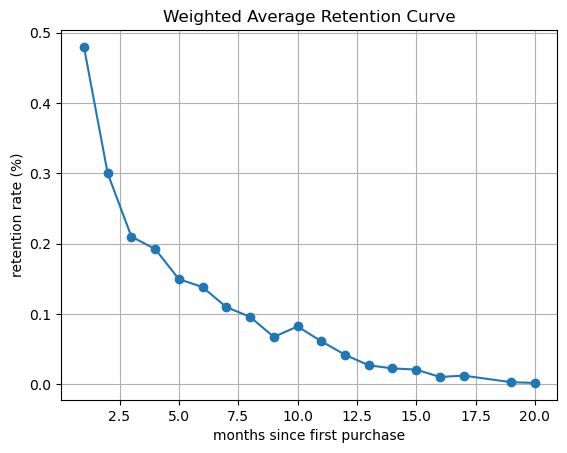

In [127]:
plt.plot(weighted_retention.index, weighted_retention.values,marker = 'o')
plt.title('Weighted Average Retention Curve')
plt.xlabel('months since first purchase')
plt.ylabel('retention rate (%)')
plt.grid(True)

# Weighted Average Retention Curve - Key Insights

The weighted retention curve shows a sharp decline in customer retention immediately after the first purchase. Month 1 retention stands at approximately 0.48%, indicating that only a small fraction of customers return for a second purchase. Retention continues to decrease steadily over time, approaching near-zero levels after the first year.

This pattern suggests that business growth is driven more by first-time purchases than repeat purchases. The low repeat purchase behavior is further supported by the finding that approximately **96.88%** of customers placed only a single order during the analysis period.

Overall, the cohort analysis reveals significant customer churn and highlights an opportunity for the business to improve retention through loyalty programs, personalized marketing campaigns, and customer engagement initiatives.

### Repeat Purchase Analysis

In [132]:
repeat_customers = (df.groupby('customer_unique_id')['order_id'].nunique().gt(1).sum())

total_customers = df['customer_unique_id'].nunique()

repeat_purchase_rate = (repeat_customers / total_customers) * 100

print("Customers who only bought once: ",100- repeat_purchase_rate)

Customers who only bought once:  96.88124375624376


Only 3.12% of customers made more than one purchase during the analysis period, while 96.88% placed a single order. This further confirms the severe retention problem identified in the cohort analysis.


## Key Insights

* Customer retention declines sharply after the first purchase, indicating that converting first-time buyers into repeat customers is a major challenge.
* Approximately **96.88%** of customers placed only a single order, highlighting very low repeat purchase behavior.
* Cohorts exhibit a consistent retention pattern over time, suggesting that weak customer retention is a persistent trend rather than an issue limited to specific acquisition periods.
* Weighted average retention analysis confirms that long-term customer retention remains extremely low across the customer base.

## Business Recommendations

1. Introduce loyalty and rewards programs to encourage customers to make second and third purchases.
2. Launch personalized email, SMS, and remarketing campaigns to re-engage first-time buyers before they churn.
3. Identify high-value customer segments through RFM analysis and target them with exclusive offers and personalized promotions.
4. Improve the post-purchase customer experience through follow-up communication, product recommendations, and incentives for repeat purchases.

## Conclusion

This cohort analysis reveals a significant customer retention problem within the Olist e-commerce dataset. Although the dataset contains a large number of first-time purchases, only **0.48%** of customers returned in the month following their first purchase, while **96.88%** placed only a single order. These findings indicate that sustainable business growth depends not only on acquiring new customers but also on improving customer retention. Investing in loyalty programs, personalized marketing, and customer engagement strategies can help increase repeat purchases and maximize customer lifetime value.
